# Day 14(M4 Day01) 실습 — LangGraph State·Node·Edge와 흐름 제어 기초

**목표**: State·Node·Edge로 기본 그래프를 만들고, 조건 분기·반복(루프)을 구현하며, 도구 에이전트를 그래프로 재구성한다.
**구성**: Part 1 기본 그래프(+엣지·State 오류 2종) → Part 2 조건 분기·반복(+재귀 한도 재현+재고 확인 도메인 반복) → Part 3 도구 에이전트 재구성(+M1 Day04 방어+M3 Day01 지식 검색을 결합한 LangGraph 면접 코치)

> **참고:** 실습 전 가상환경 활성화, `.env`의 `OPENAI_API_KEY`를 확인한다. `uv add langgraph`가 필요하다(이미 설치돼 있다면 생략). 오늘부터 M4(흐름 제어) 모듈이다 — llm-dev의 마지막 모듈이다.

### 시작 전에 — 에이전트와 워크플로, 무엇이 다른가

오늘부터 배우는 LangGraph는 **개발자가 흐름을 미리 고정한 워크플로**를 만드는 도구다. M2에서 배운 `create_agent`는 반대로 **LLM이 매 순간 다음 행동을 스스로 정하는 자유형 에이전트**였다.

| | 자유형 에이전트(M2 `create_agent`) | 고정 워크플로(오늘부터 LangGraph) |
| --- | --- | --- |
| 경로 | 매번 LLM이 판단해서 정함 | 개발자가 미리 정해둠 |
| 신뢰성·재현성 | 같은 입력에도 경로가 달라질 수 있음 | 항상 같은 경로를 탐 |
| 비용 | LLM이 판단할 때마다 호출 발생 | 필요한 지점에서만 호출 |
| 디버깅 | 실패 지점을 특정하기 어려움 | 어느 노드에서 실패했는지 바로 보임 |
| 적합한 상황 | 태스크의 경로 자체가 불확실할 때 | 태스크의 경로가 미리 알려져 있을 때 |

에이전트의 자율성은 **경로가 불확실할 때만** 값어치가 있다. "무엇을 언제 어떤 순서로 할지" 미리 아는 작업이라면, 매번 LLM이 판단하게 두는 것보다 고정된 흐름(오늘 배울 LangGraph)이 더 저렴하고 예측 가능하다.

## 0. 환경 준비

In [37]:
import os, operator
os.environ["LANGSMITH_TRACING"] = "false"
os.environ["LANGCHAIN_TRACING_V2"] = "false"

from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END

print("준비 완료")

준비 완료


## Part 1. 기본 그래프 — 기초

완성 코드를 직접 쳐서 State를 정의하고, 노드·엣지를 이어 그래프를 실행한다.

### 1-1. State 정의

흐름을 오가며 들고 다닐 값을 정한다(text는 덮어쓰기, steps는 누적).

In [38]:
class Person(TypedDict):
    name: str
    age: int

In [39]:
user: Person = {"name": "Alice", "age": 30} # TypeDict
user, type(user)

({'name': 'Alice', 'age': 30}, dict)

In [40]:
# TODO: text(str)는 덮어쓰기, steps(list, operator.add로 누적)를 담는 State(TypedDict)를 정의하세요

class State(TypedDict):
    text: str
    steps: Annotated[list, operator.add] # +, append, Reducer

print("State 정의 완료")

State 정의 완료


In [41]:
state: State = {
    "text": "Hello",
    "steps": ["start"]
}
state

{'text': 'Hello', 'steps': ['start']}

### 1-2. 노드 작성·추가

노드는 State를 받아 바뀐 값만 돌려주는 함수다.

In [42]:
# 파이썬 함수 >>>> 노드 : 스테이트를 받아서 일을 수행하고 결과를 스테이트에 반영하는 함수
def clean(s): return {"text":s["text"].strip(), "steps":["clean"]}
def upper(s): return {"text":s["text"].upper(), "steps":["upper"]}

In [43]:
# TODO: State로 StateGraph를 만들고(g), clean·upper 노드를 add_node로 추가하세요

# state 딕셔너리를 들고 다니는 그래프 g 생성
g = StateGraph(State) 

g.add_node("clean", clean)
g.add_node("upper", upper)

print("노드 추가 완료")

노드 추가 완료


In [44]:
g.state_schema

__main__.State

In [45]:
g.__annotations__

{'edges': 'set[tuple[str, str]]',
 'nodes': 'dict[str, StateNodeSpec[Any, ContextT]]',
 'branches': 'defaultdict[str, dict[str, BranchSpec]]',
 'channels': 'dict[str, BaseChannel]',
 'managed': 'dict[str, ManagedValueSpec]',
 'schemas': 'dict[type[Any], dict[str, BaseChannel | ManagedValueSpec]]',
 'waiting_edges': 'set[tuple[tuple[str, ...], str]]',
 'compiled': 'bool',
 'state_schema': 'type[StateT]',
 'context_schema': 'type[ContextT] | None',
 'input_schema': 'type[InputT]',
 'output_schema': 'type[OutputT]'}

In [46]:
State.__annotations__

{'text': str, 'steps': typing.Annotated[list, <built-in function add>]}

### 1-3. 엣지 연결·컴파일

START에서 시작해 노드를 잇고 END로 끝낸다.

In [47]:
# TODO: START->clean->upper->END 순서로 add_edge를 이어 app = g.compile()로 완성하세요
g.add_edge(START, "clean")
g.add_edge("clean", "upper")
g.add_edge("upper", END)

app = g.compile()

print("그래프 완성")

그래프 완성


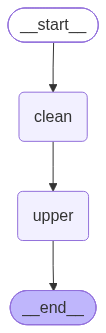

In [48]:
app

### 1-4. 실행·State 변화 관찰

text가 정리·대문자화되고 steps가 누적되는지 본다.

In [49]:
# TODO: app.invoke로 {"text": "   hello   ", "steps": []}를 실행해 result에 저장하세요

result = app.invoke( {"text": "   hello   ", "steps": []} )
print(result)

{'text': 'HELLO', 'steps': ['clean', 'upper']}


### 1-5. 그래프 구조 보기

`draw_mermaid()`로 상자-화살표 구조를 문자열로 출력한다.

In [50]:
app.get_graph().draw_mermaid()

'---\nconfig:\n  flowchart:\n    curve: linear\n---\ngraph TD;\n\t__start__([<p>__start__</p>]):::first\n\tclean(clean)\n\tupper(upper)\n\t__end__([<p>__end__</p>]):::last\n\t__start__ --> clean;\n\tclean --> upper;\n\tupper --> __end__;\n\tclassDef default fill:#f2f0ff,line-height:1.2\n\tclassDef first fill-opacity:0\n\tclassDef last fill:#bfb6fc\n'

### 1-6. 오류 대응 ① — 존재하지 않는 노드로 엣지를 연결하면?

`add_node`로 추가하지 않은 이름을 `add_edge`의 목적지로 쓰면 어떻게 되는지 확인한다.

In [ ]:

# TODO: 존재하지 않는 노드 이름("ghost_node")으로 add_edge("f", "ghost_node")를 하고 compile해보세요


> **주의:** 결과는 실제 실행에서 직접 확인한다. 엣지는 실제로 존재하는 노드끼리만 이을 수 있다 — `compile()` 시점에 그래프 구조 자체를 검증하기 때문에, 노드 이름 오타는 실행 전에 걸러진다.

### 1-7. 오류 대응 ② — State에 필수 키를 빠뜨리고 실행하면?

`invoke()`에 State가 요구하는 키를 안 넣으면 어떻게 되는지 확인한다.

In [51]:
# result = app.invoke({})

In [52]:
# TODO: 필수 키 text를 빼고 app3.invoke({})를 실행해 r3에 저장해보세요

try:
    result = app.invoke({})
except Exception as e:
    print(type(e).__name__, "-", e)

KeyError - 'text'


> **주의:** 결과는 실제 실행에서 직접 확인한다. `TypedDict`는 파이썬 타입 힌트일 뿐 강제 검증이 아니다 — 노드 함수 안에서 실제로 그 키에 접근하는 순간(`s["text"]`) 없으면 오류가 난다. `compile()` 단계가 아니라 **그 키를 실제로 쓰는 노드가 실행되는 시점**에 드러난다.

### 관찰 정리

- 1-6·1-7에서 확인한 두 오류는 각각 언제(컴파일 시점 vs 실행 시점) 드러났는가?
- 노드가 State에 없는 키를 돌려주면 어떻게 될까? (직접 실험해 보아도 좋다)

## Part 2. 조건 분기·반복 — 응용

State를 보고 다음 상자를 고르고(분기), 조건이 찰 때까지 되돌아간다(반복).

### 2-1. 조건 분기 — 갈림길

조건 함수가 State를 보고 다음 노드 이름을 돌려준다.

In [53]:
class BranchState(TypedDict):
    n: int
    path: str

In [54]:
def check(s): return {}
def even(s): return {'path': '짝수'}
def odd(s): return {'path': '홀수'}

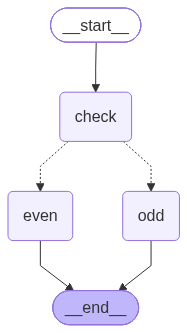

In [55]:

# TODO: State의 n이 짝수면 "even", 홀수면 "odd"를 반환하는 route 함수를 만드세요

#조건분기 노드
def route(s):
    return "even" if s["n"] %2 == 0 else "odd"

gb = StateGraph(BranchState)
gb.add_node("check", check)
gb.add_node("even", even)
gb.add_node("odd", odd)

gb.add_edge(START, "check")
# TODO: check 다음에 route로 분기해 "even"/"odd" 노드로 보내는 add_conditional_edges를 만드세요
gb.add_conditional_edges("check", route, {"even":"even", "odd":"odd" })
gb.add_edge("even", END)
gb.add_edge("odd", END)

app_b = gb.compile()
app_b


In [56]:
BranchState.__annotations__

{'n': int, 'path': str}

In [57]:
app_b.invoke({"n":10, "path":""})

{'n': 10, 'path': '짝수'}

In [58]:
app_b.invoke({"n":-3, "path":""})

{'n': -3, 'path': '홀수'}

In [59]:
app_b.invoke({"n":0, "path":""})

{'n': 0, 'path': '짝수'}

### 2-2. 반복(루프) — 되돌아가기

조건 엣지로 자기 자신에게 되돌아가면 반복이 된다.

start -> tick -> cont() n<3 -> tick, n>=3 end -> __end__

In [60]:
class LoopState(TypedDict):
    n: int
    steps: Annotated[list, operator.add]

In [61]:
# tick 노드 : 현재 n에 -1 > steps에 n=증가한 값을 저장하는 노드
def tick(s): return {"n": s["n"]+1, "steps":[f'n = {s["n"]+1}']}

# TODO: n<3이면 "tick", 아니면 "end"를 반환하는 cont 함수를 만드세요
# cont 노드 : 조건노드 > 다음에 어디로 갈지 정해준다
def cont(s): return "tick" if s["n"] < 3 else "end"

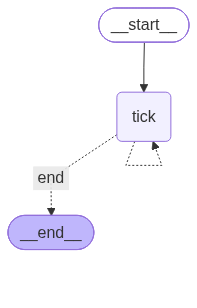

In [62]:
# 그래프 생성
gc = StateGraph(LoopState)

# 노드 추가
gc.add_node("tick", tick)

# 엣지 추가
gc.add_edge(START, "tick")
# TODO: tick 다음에 cont로 분기해 "tick"이면 자기 자신, "end"면 END로 보내는
#       add_conditional_edges를 만드세요
gc.add_conditional_edges("tick", cont, {"tick":"tick", "end":END })

# 그래프 컴파일
app_c = gc.compile()
app_c

In [63]:
LoopState.__annotations__

{'n': int, 'steps': typing.Annotated[list, <built-in function add>]}

In [64]:
app_c.invoke({"n":0, "steps":['시작']})


{'n': 3, 'steps': ['시작', 'n = 1', 'n = 2', 'n = 3']}

In [65]:
app_c.invoke({"n":10, "steps":['시작']})

{'n': 11, 'steps': ['시작', 'n = 11']}

In [66]:
# 파이썬 코드로 작성하기
n = 0
steps = []

while( n < 3):
    n += 1
    steps.append(f'n={n}')

steps

['n=1', 'n=2', 'n=3']

### 2-3. 재귀 한도 초과 재현

종료 조건이 없는 루프를 만들어 무한 반복이 실제로 막히는지 확인한다.

In [67]:
#무한루프 조건노드
def cont_forever(s): return "tick"   # 종료 조건 없음(항상 tick으로)

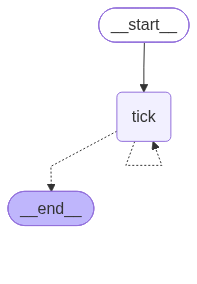

In [68]:
# TODO: app_c.invoke로 {"n": 0, "steps": []}인 무한 루프를 실행해 r_forever에 저장하세요
# 그래프 생성
gd = StateGraph(LoopState)

# 노드 추가
gd.add_node("tick", tick)

# 엣지 추가
gd.add_edge(START, "tick")
gd.add_conditional_edges("tick", cont_forever, {"tick": "tick"}) #항상 tick

# 그래프 컴파일
app_c = gd.compile()
app_c

In [69]:
LoopState.__annotations__

{'n': int, 'steps': typing.Annotated[list, <built-in function add>]}

In [70]:
r_forever = []
try:
    r_forever = gd.invoke({"n": 0, "steps": []})
    print(r_forever)
except Exception as e:
    print("오류 발생:", type(e).__name__, "-", str(e)[:120])


오류 발생: AttributeError - 'StateGraph' object has no attribute 'invoke'


> **참고:** 결과는 실제 실행에서 직접 확인한다. 종료 조건 없는 루프는 LangGraph의 재귀 한도에 걸려 오류로 멈춘다 — 그래도 이 한도에 기대지 말고, **항상 직접 종료 조건을 설계**해야 한다(2-2처럼).

### 관찰 정리

| 흐름 | 구성 | 멈추는 법 |
| --- | --- | --- |
| 분기 | 조건 함수 → 노드 지도 | 각 갈래가 END로 |
| 반복 | 조건 엣지가 자기에게 회귀 | 종료 조건이 "end" 반환 |

In [ ]:
# 미션

# CoffeeState를 정의하세요 > temperature, steps 정의

# 노드 cool 을 정의하세요 > temperature 가 10도씩 내려갑니다.

# 조건노드 check_temperature 를 정의하세요 : temperature가 < 60 일때 "drink", 아니면 cool 노드로 분기

# 조건엣지를 정의하세요 : "cool" 이면 cool 노드, "drink" 이면 end 노드

# 커피 온도가 내려갈떄까지 기다려 주는 에이전트 실행

In [100]:
# CoffeeState를 정의하세요 > temperature, steps 정의
class CoffeeState(TypedDict):
    temperature: int
    steps: Annotated[list, operator.add]

In [ ]:
# 노드 cool 을 정의하세요 > temperature 가 10도씩 내려갑니다.
def cool(s): 
    temp = s["temperature"] - 10
    return {"temperature": temp, "steps":[f'커피온도: {temp}도']}

# 조건노드 check_temperature 를 정의하세요 : temperature가 < 60 일때 "drink", 아니면 cool 노드로 분기
def check_temperature(s): 
    return "drink" if s["temperature"] < 60 else "cool"

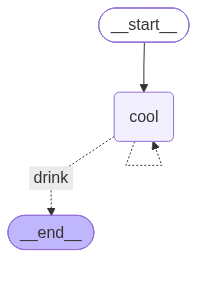

In [107]:
# 그래프 생성
coffee_grapth = StateGraph(CoffeeState)

# 노드 추가
coffee_grapth.add_node("cool", cool)

# 엣지 추가
coffee_grapth.add_edge(START, "cool")

# 조건엣지를 정의하세요 : "cool" 이면 cool 노드, "drink" 이면 end 노드
coffee_grapth.add_conditional_edges("cool", check_temperature, {"cool":"cool", "drink":END })

# 그래프 컴파일
app_coffee = coffee_grapth.compile()
app_coffee

In [108]:
CoffeeState.__annotations__

{'temperature': int, 'steps': typing.Annotated[list, <built-in function add>]}

In [110]:
# 커피 온도가 내려갈떄까지 기다려 주는 에이전트 실행
app_coffee.invoke({"temperature": 95, "steps": ['커피 완성']})

{'temperature': 55,
 'steps': ['커피 완성', '커피온도: 85도', '커피온도: 75도', '커피온도: 65도', '커피온도: 55도']}

### 2-4. 다른 도메인 반복 — 재고 확인·재입고 흐름

같은 방법(분기+반복)을 다른 도메인에도 적용해본다. 이번엔 재고량에 따라 분류하고, 부족하면 재입고를 반복한다.

In [111]:
# 상태 클래스
class StockState(TypedDict):
    stock: int
    status: str

입력 상태 > check_stock > route_stock : normal | low | out

In [113]:
def normal(s):
    return {"status": "정상 재고, 판매 가능"}

def low(s):
    return {"status": "재고 부족 - 발주 필요"}

def out(s):
    return {"status": "품절"}

def check_stock(s):
    print(f"현재 재고를 확인합니다 : {s['stock']}개")
    return {}

In [115]:
# TODO: stock이 10 초과면 "normal", 0 초과면 "low", 그 외엔 "out"을 반환하는 route_stock 함수를 만드세요
# 조건 노드
def route_stock(s):
    if s['stock'] > 10: return "normal"
    elif s['stock'] > 0: return "low"
    else: return "out"

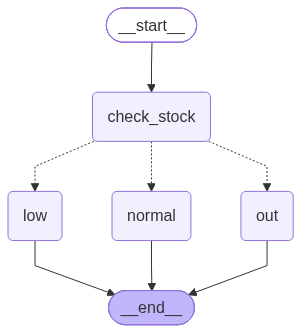

In [120]:
# 그래프 구성
gs = StateGraph(StockState)
gs.add_node("check_stock", check_stock)
gs.add_node("normal", normal)
gs.add_node("low", low)
gs.add_node("out", out)

gs.add_edge(START, "check_stock")
gs.add_conditional_edges("check_stock", route_stock, {"normal":"normal", "low":"low", "out": "out" })
gs.add_edge("normal", END)
gs.add_edge("low", END)
gs.add_edge("out", END)

app_stock = gs.compile()
app_stock

In [121]:
StockState.__annotations__

{'stock': int, 'status': str}

In [129]:
stock_list = [30, 0, 5, 10]
for stock in stock_list:
    print(f"재고 {stock}",app_stock.invoke({'stock': stock, 'status': []}))
    print('-' * 100)

현재 재고를 확인합니다 : 30개
재고 30 {'stock': 30, 'status': '정상 재고, 판매 가능'}
----------------------------------------------------------------------------------------------------
현재 재고를 확인합니다 : 0개
재고 0 {'stock': 0, 'status': '품절'}
----------------------------------------------------------------------------------------------------
현재 재고를 확인합니다 : 5개
재고 5 {'stock': 5, 'status': '재고 부족 - 발주 필요'}
----------------------------------------------------------------------------------------------------
현재 재고를 확인합니다 : 10개
재고 10 {'stock': 10, 'status': '재고 부족 - 발주 필요'}
----------------------------------------------------------------------------------------------------


StockState : stock, status -> status 값 설정
RestockState : stock, attemp -> 제고 변경 과정 누적

In [139]:
class RestockState(TypedDict):
    stock: int
    attempt: Annotated[list, operator.add] #Reducer

In [152]:
def restock(s): return {"stock": s['stock']+5, "attempts": f"입고 후 재고: {s['stock']+5}"}

In [147]:
# TODO: stock이 10 미만이면 "restock", 아니면 "done"을 반환하는 restock_route 함수를 만드세요
# 조건 노드 정의
def restock_route(s):
    return "restock" if s["stock"] < 10 else "done"

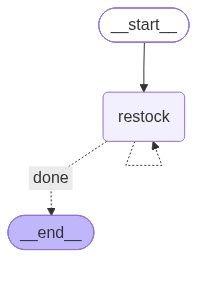

In [153]:
gr = StateGraph(RestockState)


gr.add_node("restock", restock)

gr.add_edge(START, "restock")
gr.add_conditional_edges("restock", restock_route, {"restock":"restock", "done":END })

app_r = gr.compile()
app_r

# app_stock2

In [163]:
#초기 제고는 2이고, restock 노드가 실행될 때마다 재고를 5씩 추가합니다.
result1 = app_r.invoke({"stock": 2, "attemps": []})
result2 = app_r.invoke(result1)
print(result2)

{'stock': 17, 'attempt': []}


### 관찰 정리

- 숫자 홀짝 도메인과 재고 도메인 모두에서, 분기·반복 구조가 그대로 통했는가?
- `restock` 루프는 몇 번 반복하고 멈췄는가? 종료 조건은 무엇이었는가?

### 2-5. 병렬화 — Send로 동시에 처리하기

지금까지의 분기는 여러 갈래 중 **하나**를 골랐다. 병렬화는 여러 갈래를 **동시에 전부** 실행하고 결과를 모으는 것이다 — 서로 독립적인 하위 작업(예: 리뷰를 여러 관점에서 평가)에 적합하다.

In [72]:
from langgraph.types import Send

In [73]:
class NumberState(TypedDict):
    numbers: list[int]
    results: Annotated[list[int], operator.add]

In [74]:
def fan_out(state):
    return [Send("double", {"number": n}) for n in state['numbers']] # numbers = 3 -> 1,2,3 각각의 Send 를 리스트에 담아서 리턴한다.

double 이라는 노드를 만든다.
시작 -> Send : number=1, 2, 3 -> double: *2 > 2,4,6 -> END 

In [75]:
def double(state):
    number = state["number"]
    return {"results": [number * 2]}

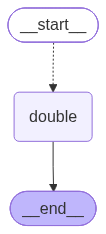

In [76]:
gd = StateGraph(NumberState)
gd.add_node("double", double)
gd.add_conditional_edges(START, fan_out, ["double"])
gd.add_edge("double", END)
app = gd.compile()
app

In [77]:
NumberState.__annotations__

{'numbers': list[int],
 'results': typing.Annotated[list[int], <built-in function add>]}

In [78]:
result = app.invoke({"numbers":[1,2,3], "results":[]})

print("최종 결과 : ", result["results"])

최종 결과 :  [2, 4, 6]


리뷰의 평가 관점 입력

fan_out

각 관점별 작업 생성

배송    포장    가격

evaluate_aspect 병렬

conbine

summary 생성

In [96]:
# ReviewState 정의 - review, aspects[], results[], summary
class ReviewState(TypedDict):
    review: str # 원본 리뷰
    aspects: list # 평가관렴 목록
    results: Annotated[list, operator.add] # 평가관점별 평가결과를 병렬로 채우는 reducer
    summary: str    # 관점별 평가를 합친 최종 결과

In [102]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
load_dotenv()

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)   # temperature=0: 결과 재현성

In [103]:
# evaluate_aspect, combine 노드 정의

def evaluate_aspect(state):
    #llm 호출 > 관점에 따른 리뷰 평가
    result = llm.invoke(f"다음 리뷰를 '{state['aspect']}'관점에서만 "
               f"한 문장으로 평가해줘 : {state['review']}"
               ).content
   
    return {"results": [f"[{state['aspect']}] {result}"]}

def combine(state):
    return {"summary": "\n".join(state['results'])}


In [104]:
# TODO: aspects 각각에 대해 evaluate_aspect 노드를 독립적으로(병렬로) 실행하도록
#       Send("evaluate_aspect", {...}) 리스트를 반환하는 fan_out 함수를 작성하세요

# 조건 노드 fan_out
def fan_out(state: ReviewState):
    return [
        Send("evaluate_aspect", {"review": state["review"],
                                 "aspect": aspect
            }) for aspect in state['aspects']
    ]


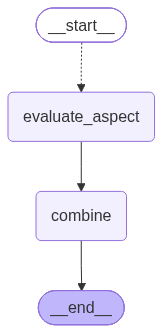

In [105]:
# 그래프 구성
gd = StateGraph(ReviewState)

gd.add_node("evaluate_aspect", evaluate_aspect)
gd.add_node("combine", combine)

gd.add_conditional_edges(START, fan_out, ["evaluate_aspect"]) #병렬로 호출, 입력받은 관점의 갯수만큼

gd.add_edge("evaluate_aspect", "combine")
gd.add_edge("combine", END)

# 그래프 생성
app_paralle1 = gd.compile()
app_paralle1

In [106]:
ReviewState.__annotations__

{'review': str,
 'aspects': list,
 'results': typing.Annotated[list, <built-in function add>],
 'summary': str}

In [107]:
# 그래프 실행
result = app_paralle1.invoke({
    "review": "배송은 빨랐지만 포장이 부실했고, 가격 대비 품질은 괜찮았어요.",
    "aspects": ["배송", "포장", "가격"],
    "results":[],
})

print(result["summary"])

[배송] 배송은 빨랐지만 포장이 부실했다.
[포장] 포장이 부실했지만 가격 대비 품질은 괜찮았습니다.
[가격] 가격 대비 품질이 괜찮았지만, 포장이 부실한 점이 아쉬웠습니다.


In [ ]:
# 병령 처리 그래프의 실행
result = app_paralle1.invoke({
    "review": "화면은 깔끔하고 사용하기 편했지만, 실행 속도가 느리고 오류가 자주 발생했어요.",
    "aspects": ["디자인", "사용성", "성능", "안정성"],
    "results":[],
})

print(result["summary"])

[디자인] 디자인은 깔끔하고 사용자 친화적이지만, 실행 속도와 안정성 문제로 전체적인 사용자 경험이 저하되었습니다.
[사용성] 사용성 측면에서 화면은 깔끔하고 편리했으나, 느린 실행 속도와 잦은 오류로 인해 전반적인 사용자 경험이 저하되었습니다.
[성능] 성능 측면에서 실행 속도가 느리고 오류가 자주 발생해 사용에 불편함이 있었습니다.
[안정성] 화면은 깔끔하고 사용하기 편했으나, 실행 속도가 느리고 오류가 자주 발생하여 안정성이 부족하다고 평가할 수 있습니다.


### 2-6. 오케스트레이터-워커 — 매니저가 작업을 나누고 워커가 처리하기

2-5의 병렬화는 `aspects` 목록을 **미리 정해서** 넘겼다. 오케스트레이터-워커는 그 목록 자체를 **매니저 LLM이 그때그때 정하고**, 정해진 하위 작업들을 워커 LLM들에게 나눠 맡긴 뒤 결과를 종합한다.

요청 -> 오케스트레이터 노드 : 작업 계획 수립, 분배 -> 워커1, 워커2, .... 작업 수행 -> 취합

- 보고서 작성요청 -> 시장, 기술, 위험 > 분배 > 취합
- 코드 검토 -> 보안, 성능, 가독성, 표준 위험 관점 검토 > 취합

In [ ]:
# TODO: 이 타스크를 검토할 서브타스크 2~4개를 한 줄에 하나씩만 나열하도록 llm.invoke로 요청하고,
#       줄 단위로 나눠 subtasks 리스트를 만드는 orchestrator 함수를 작성하세요
#       (참고: plan.strip().split("\n")으로 줄 단위 분리)

In [134]:
# OrchestratorState 정의 - task, subtasks[], worker_results[], final_report
class OrchestratorState(TypedDict):
    task: str                                       # 요청에 받은 검토내용
    subtasks: list                                   # llm이 서브타스크 생성 - orchestrator 노드
    worker_results: Annotated[list, operator.add]   # worker 들이 병렬로 실행해서 채운다
    final_report :str                               # llm이 worker_results로 최종보고서 생성 - aggregator 노드

In [135]:
# orchestrator 함수 - 서브타스크 분할 노드
def orchestrator(state: OrchestratorState):
    # 매니저 LLM 에게 작업을 검토하게 한다. > 서브타스크 목록 도출 ** 갯수가 정해져 있지 않음
    plan = llm.invoke(f"다음 작업을 검토할 하위 관점을 2~4개를 한 줄에 하나씩(설명 없이 관점 이름만) : {state['task']} ").content
    subtasks = [s.strip("- ").strip() for s in plan.strip().split("\n") if s.strip() ] #서브타스크 목록
    print(subtasks)
    return {"subtasks": subtasks}

In [136]:
# 워커 지정 노드 assign_workers 
def assign_workers(state: OrchestratorState):
    return [Send("worker", {"task":state['task'], "subtask": subtask}) for subtask in state['subtasks']]

In [137]:
# 워커 노드 worker
def worker(state: OrchestratorState):
    result = llm.invoke(f"다음 작업을"
                        f"{state['subtask']} 관점에서 검토한 다음 2~3문장으로 피드백하세요.\n"
                        f": {state['task']}"
                        ).content
    return {"worker_results": [f"[{state['subtask']}] {result}"]} #[UI디자인] ㅇㅇㅇㅇㅇㅇ

In [138]:
# 취합 노드 aggregator
def aggregator(state: OrchestratorState):
    combined = "\n".join(state['worker_results'])
    final = llm.invoke(f"아래 관점별 피드백을 종합해서 하나의 검토 보고서로 정리하세요.\n\n"
                        f": {combined}").content
    return {"final_report": final} 

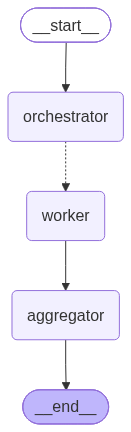

In [139]:
# 그래프 구성
gf = StateGraph(OrchestratorState)

gf.add_node("orchestrator", orchestrator)
gf.add_node("worker", worker)
gf.add_node("aggregator", aggregator)

gf.add_edge(START, "orchestrator")

gf.add_conditional_edges("orchestrator", assign_workers, ["worker"])

gf.add_edge("worker", "aggregator")
gf.add_edge("aggregator", END)

# 그래프 생성
app_orchestrator = gf.compile()
app_orchestrator

In [140]:
# 그래프 테스트
# 오케스트레이터 호출
result = app_orchestrator.invoke(
    {"task":"신규 가입 페이지 UI를 개선하는 사업계획서", "subtasks": [], "worker_results":[]}
)
print(result["final_report"])

['1. 사용자 경험(UX)', '2. 접근성', '3. 디자인 일관성', '4. 성능 최적화']
# 신규 가입 페이지 UI 개선 검토 보고서

## 1. 개요
본 보고서는 신규 가입 페이지 UI 개선을 위한 다양한 관점에서의 피드백을 종합하여 사용자 경험을 향상시키기 위한 방향성을 제시합니다. 사용자 친화적인 디자인, 접근성, 디자인 일관성, 성능 최적화 등 네 가지 주요 요소를 중심으로 검토하였습니다.

## 2. 사용자 경험(UX)
신규 가입 페이지의 UI는 사용자 친화성을 높이기 위해 간결하고 직관적인 디자인이 필요합니다. 입력 필드를 최소화하고, 시각적 피드백을 제공하여 사용자가 진행 상황을 쉽게 이해할 수 있도록 해야 합니다. 또한, 모바일 최적화를 통해 다양한 디바이스에서의 접근성을 강화하는 것이 중요합니다. 이러한 요소들은 사용자가 가입 과정을 보다 원활하게 진행할 수 있도록 도와줄 것입니다.

## 3. 접근성
접근성 측면에서 신규 가입 페이지 UI 개선 사업계획서는 다양한 요소를 고려해야 합니다. 시각적 요소의 대비를 높이고, 스크린 리더와의 호환성을 강화하며, 키보드 내비게이션을 지원하는 것이 중요합니다. 또한, 장애인 사용자와의 테스트를 포함하여 다양한 사용자 요구를 반영하는 것이 필요합니다. 이를 통해 모든 사용자가 페이지를 쉽게 이용할 수 있도록 보장해야 합니다.

## 4. 디자인 일관성
디자인 일관성은 사용자 경험을 향상시키는 중요한 요소입니다. 신규 가입 페이지의 색상, 폰트, 버튼 스타일 등이 기존 브랜드 가이드라인과 일치하는지 검토해야 하며, 사용자 경험을 고려한 직관적인 레이아웃을 적용해야 합니다. 일관된 디자인 요소는 사용자에게 신뢰감을 주고, 브랜드 인식을 강화하는 데 기여할 것입니다.

## 5. 성능 최적화
성능 최적화는 사용자 경험을 향상시키는 데 필수적인 요소입니다. 페이지 로딩 속도를 최소화하고, 불필요한 요소를 제거하여 사용자 이탈을 방지하는 것이 필요합니다. 또한, 반응형 디자인을 적용하여 다양한 디바이스에서

## Part 3. 미니 프로젝트 — 도구 에이전트를 그래프로 재구성

M2 Day04(Day08)의 `create_agent`가 내부에서 하던 일을, State·Node·Edge로 직접 조립한다.

### 3-1. 도구·모델·State

메시지를 누적하는 State와 도구를 붙인 LLM을 준비한다.

In [ ]:
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

@tool
def add(a: int, b: int) -> int:
    """두 수를 더한다."""
    return a + b

# TODO: add 도구를 bind_tools한 ChatOpenAI(temperature=0)를 llm_tools에 만들고
#       tool_map = {"add": add}를 만드세요





### 3-2. 노드·조건 엣지

llm(판단)·tools(실행) 노드와, 도구 호출 여부로 분기하는 조건 엣지를 만든다.

In [ ]:


# TODO: 마지막 메시지에 tool_calls가 있으면 "tools", 없으면 "end"를 반환하는 agent_route 함수를 만드세요

# 
# 기해 "tools"/"end"로 보내는 add_conditional_edges를 만들고
#       tools에서 다시 llm으로 돌아가는 add_edge를 추가하세요



print("에이전트 그래프 완성")

### 3-3. 실행·경로 확인

### 관찰

| 메시지 | 역할 |
| --- | --- |
| HumanMessage | 사용자 질문 |
| AIMessage(tool_calls) | LLM이 도구 호출 결정 |
| ToolMessage | 도구 실행 결과 |
| AIMessage | 근거로 만든 최종 답 |

## Part 3-확장. M1·M3 통합 — LangGraph 기반 면접 코치

위 도구 에이전트 그래프에, M3 Day01(Day10)의 임베딩 채용 공고 검색을 **도구**로 붙이고, M1 Day04의 입력·출력 방어를 그래프 바깥에서 감싼다. `create_agent` 없이도 같은 일을 그래프로 할 수 있음을 확인한다.

### 채용 공고 검색 도구 (M3 Day01 재사용)

In [ ]:
from langchain_openai import OpenAIEmbeddings
import numpy as np

emb = OpenAIEmbeddings(model="text-embedding-3-small")
job_postings = [
    "백엔드 개발자: Python/Java 기반 서버 개발, RESTful API 설계, DB 최적화 경험 우대",
    "프론트엔드 개발자: React/TypeScript, 반응형 UI 구현, 웹 접근성 이해 우대",
    "데이터 분석가: SQL/Python 데이터 분석, 대시보드 제작, 통계적 사고 우대",
    "마케터: 콘텐츠 기획, 데이터 기반 캠페인 분석, SNS 채널 운영 경험 우대",
]
# TODO: job_postings를 embed_documents로 임베딩해 job_vectors에 저장하세요


def cosine(a, b):
    a, b = np.array(a), np.array(b)
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

@tool
def search_job(interest: str) -> str:
    """관심 직무 설명을 받아 가장 관련 있는 채용 공고를 검색한다."""
    # TODO: interest를 embed_query로 벡터화하고, job_postings와의 코사인 유사도로 정렬해
    #       가장 관련 있는 공고 1개를 반환하세요




print("채용 공고 검색 도구 준비 완료")

### 방어 로직 (M1 Day04 재사용)

인젝션 방어는 M1 Day04에서 만든 것을 그대로 가져온다.

In [ ]:
# TODO: M1 Day04의 위험 문구·금지어 목록과 input_guard·output_guard를 옮겨오세요






### LangGraph 기반 면접 코치

`search_job` 도구를 붙인 새 그래프를 만들고, 방어 로직으로 감싼다.

In [ ]:

# TODO: '지원자가 관심 직무를 말하면 search_job으로 검색해 참고한다'는 SystemMessage와 question으로
#       coach_graph를 invoke해 answer를 만드세요





### 최종 테스트

In [ ]:


# TODO: 인젝션을 시도하는 질문을 넣어보세요

### M4 Day01 정리

**확인 질문**
- `graph_coach`에서 M1·M2·M3·오늘(M4) 각각에서 가져온 요소는 무엇인가?
- `create_agent`(M2)로 만든 코치와 오늘 그래프로 직접 만든 코치는 겉보기 동작이 같은가? 내부 구현은 어떻게 다른가?

## 확인 문제

1. 노드는 State 전체를 돌려주는가, 바뀐 부분만 돌려주는가?
2. 1-6·1-7에서 확인한 두 오류는 각각 언제(컴파일 시점 vs 실행 시점) 드러났는가?
3. 2-3에서 확인한 것처럼, 종료 조건 없는 루프는 어떻게 멈추는가? 이 한도에 기대도 되는가?
4. Part 2와 Part 2의 도메인 반복에서, 분기·반복 구조가 도메인이 달라도 그대로 통했는가?
5. `graph_coach`에서 도구 호출 후 왜 항상 다시 `llm` 노드로 돌아가는가?